In [10]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from transformers import BertTokenizer, BertModel
from transformers import BlipProcessor, BlipForConditionalGeneration

import easyocr
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [11]:
# ========== UPDATE THESE PATHS FOR YOUR SETUP ==========
CSV_TRAIN_PATH = "/kaggle/input/politifact-dataset/AAAI_dataset/politi_train.csv"  # Update this path
CSV_TEST_PATH = "/kaggle/input/politifact-dataset/AAAI_dataset/politi_test.csv"    # Update this path
IMG_DIR = "/kaggle/input/politifact-dataset/AAAI_dataset/Images"         # Update this path
CACHE_DIR = "./cache"                          # Cache directory for features
# ========================================================

os.makedirs(CACHE_DIR, exist_ok=True)

# Load training data
df_train = pd.read_csv(CSV_TRAIN_PATH)

# Load test data
df_test = pd.read_csv(CSV_TEST_PATH)

# Remove unnamed index column if exists
if 'Unnamed: 0' in df_train.columns:
    df_train = df_train.drop('Unnamed: 0', axis=1)
if 'Unnamed: 0' in df_test.columns:
    df_test = df_test.drop('Unnamed: 0', axis=1)

# Label mapping (already 0 and 1, but confirming)
# 0 = fake news, 1 = real news
print(f"Training samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print(f"\nTraining Label Distribution:\n{df_train['label'].value_counts()}")
print(f"\nTest Label Distribution:\n{df_test['label'].value_counts()}")
print("\nSample data:")
df_train.head()

Training samples: 381
Test samples: 104

Training Label Distribution:
label
1    246
0    135
Name: count, dtype: int64

Test Label Distribution:
label
1    75
0    29
Name: count, dtype: int64

Sample data:


,content,image,label
0,Democrats go full TYRANNY: Now demand nationwi...,0fAqwAY4nXClIPGFaiu3Awb9uFuHUtLi.jpg,0
1,Inside a Fake News Sausage Factory: ‘This Is A...,0N870INRRf8SIlsMIRUqBEjXnoIyl09B.jpg,0
2,"Palin: Pioneer, maverick -- and now game-chang...",0xeeIMPb2lo1HHb6UkI9UfpgzOWopP5F.jpg,1
3,Sasse Statement on Trade War U.S. Senator Ben ...,195zVDZhCOMVzF5wyQvlLEN3jsden4Et.jpg,1
4,"Health Reform Carries Heavy Price, Insurers Cl...",1edVjMROUH27MDyX7HxeVcigneIEmYlX.jpg,1


In [12]:
# BERT for text encoding
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased").to(device)
for p in bert.parameters():
    p.requires_grad = False

# ResNet50 for image encoding
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)
resnet.fc = nn.Identity()  # Remove final classification layer
for p in resnet.parameters():
    p.requires_grad = False

# EasyOCR for text extraction from images
ocr_reader = easyocr.Reader(['en'])

# BLIP for image captioning
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("✓ All models loaded and frozen")

✓ All models loaded and frozen


In [13]:
def extract_text_features(text, max_length=512):
    """
    Extract BERT features from text content
    """
    if pd.isna(text) or text.strip() == "":
        return torch.zeros(768).to(device)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding="max_length"
    ).to(device)
    
    with torch.no_grad():
        outputs = bert(**inputs)
        # Use [CLS] token embedding
        cls_embedding = outputs.last_hidden_state[:, 0, :]
    
    return cls_embedding.squeeze()


def extract_image_features(image_path):
    """
    Extract ResNet features from image
    """
    if not os.path.exists(image_path):
        print(f"Warning: Image not found - {image_path}")
        return torch.zeros(2048).to(device)
    
    try:
        img = Image.open(image_path).convert('RGB')
        
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
        
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            features = resnet(img_tensor)
        
        return features.squeeze()
    
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return torch.zeros(2048).to(device)


def extract_ocr_text(image_path):
    """
    Extract text from image using OCR
    """
    if not os.path.exists(image_path):
        return ""
    
    try:
        result = ocr_reader.readtext(image_path)
        ocr_text = " ".join([text[1] for text in result])
        return ocr_text
    except Exception as e:
        print(f"OCR Error for {image_path}: {e}")
        return ""


def generate_image_caption(image_path):
    """
    Generate caption for image using BLIP
    """
    if not os.path.exists(image_path):
        return ""
    
    try:
        img = Image.open(image_path).convert('RGB')
        inputs = blip_processor(img, return_tensors="pt").to(device)
        
        with torch.no_grad():
            out = blip_model.generate(**inputs, max_length=50)
        
        caption = blip_processor.decode(out[0], skip_special_tokens=True)
        return caption
    
    except Exception as e:
        print(f"Caption Error for {image_path}: {e}")
        return ""


print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


In [14]:
def process_dataset(df, dataset_name="train"):
    """
    Process entire dataset and extract all features
    """
    cache_file = os.path.join(CACHE_DIR, f"{dataset_name}_features.pt")
    
    # Check if cached features exist
    if os.path.exists(cache_file):
        print(f"Loading cached features from {cache_file}")
        return torch.load(cache_file)
    
    print(f"Processing {dataset_name} dataset...")
    
    all_features = []
    all_labels = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        # Get content text
        content_text = row['content']
        
        # Get image path
        image_filename = row['image']
        image_path = os.path.join(IMG_DIR, "politi_train", image_filename)
        
        # Get label
        label = row['label']
        
        # Extract features
        text_features = extract_text_features(content_text)
        image_features = extract_image_features(image_path)
        
        # Extract OCR text and get its features
        ocr_text = extract_ocr_text(image_path)
        ocr_features = extract_text_features(ocr_text) if ocr_text else torch.zeros(768).to(device)
        
        # Generate image caption and get its features
        caption = generate_image_caption(image_path)
        caption_features = extract_text_features(caption) if caption else torch.zeros(768).to(device)
        
        # Concatenate all features
        combined_features = torch.cat([
            text_features,      # 768 dim from content text
            image_features,     # 2048 dim from image
            ocr_features,       # 768 dim from OCR text
            caption_features    # 768 dim from image caption
        ])
        
        all_features.append(combined_features.cpu())
        all_labels.append(label)
    
    # Stack into tensors
    features_tensor = torch.stack(all_features)
    labels_tensor = torch.tensor(all_labels, dtype=torch.long)
    
    # Save to cache
    torch.save({
        'features': features_tensor,
        'labels': labels_tensor
    }, cache_file)
    
    print(f"Features saved to {cache_file}")
    print(f"Feature shape: {features_tensor.shape}")
    
    return {'features': features_tensor, 'labels': labels_tensor}


# Process training data
train_data = process_dataset(df_train, "politifact_train")

# Process test data
test_data = process_dataset(df_test, "politifact_test")

Loading cached features from ./cache/politifact_train_features.pt
Loading cached features from ./cache/politifact_test_features.pt


In [15]:
class FakeNewsClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout=0.3):
        super(FakeNewsClassifier, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(hidden_dim // 2, 2)  # Binary classification (fake/real)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x


# Get input dimension (768 + 2048 + 768 + 768 = 4352)
input_dim = train_data['features'].shape[1]
print(f"Input dimension: {input_dim}")

# Initialize model
model = FakeNewsClassifier(input_dim=input_dim).to(device)
print(model)

Input dimension: 4352
FakeNewsClassifier(
  (fc1): Linear(in_features=4352, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=2, bias=True)
)


In [16]:
from torch.utils.data import TensorDataset

# Create datasets
train_dataset = TensorDataset(train_data['features'], train_data['labels'])
test_dataset = TensorDataset(test_data['features'], test_data['labels'])

# Create dataloaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 24
Test batches: 7


In [18]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Training parameters
NUM_EPOCHS = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

print("✓ Training setup complete")

✓ Training setup complete


In [19]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * val_correct / val_total
    
    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    
    # Print epoch results
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), os.path.join(CACHE_DIR, 'best_model.pt'))
        print("✓ Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

print("\n✓ Training completed!")

Epoch 1/30 [Train]: 100%|██████████| 24/24 [00:00<00:00, 58.44it/s]



Epoch [1/30]
Train Loss: 0.4686 | Train Acc: 78.74%
Val Loss: 0.4055 | Val Acc: 81.73%
✓ Best model saved


Epoch 2/30 [Train]: 100%|██████████| 24/24 [00:00<00:00, 343.83it/s]



Epoch [2/30]
Train Loss: 0.2904 | Train Acc: 89.24%
Val Loss: 0.3721 | Val Acc: 84.62%
✓ Best model saved


Epoch 3/30 [Train]: 100%|██████████| 24/24 [00:00<00:00, 348.54it/s]


...


Epoch [5/30]
Train Loss: 0.1394 | Train Acc: 95.28%
Val Loss: 0.4689 | Val Acc: 82.69%


Epoch 6/30 [Train]: 100%|██████████| 24/24 [00:00<00:00, 353.87it/s]



Epoch [6/30]
Train Loss: 0.1207 | Train Acc: 97.38%
Val Loss: 0.4552 | Val Acc: 84.62%


Epoch 7/30 [Train]: 100%|██████████| 24/24 [00:00<00:00, 364.27it/s]


Epoch [7/30]
Train Loss: 0.0597 | Train Acc: 98.43%
Val Loss: 0.5133 | Val Acc: 81.73%

Early stopping triggered after 7 epochs

✓ Training completed!


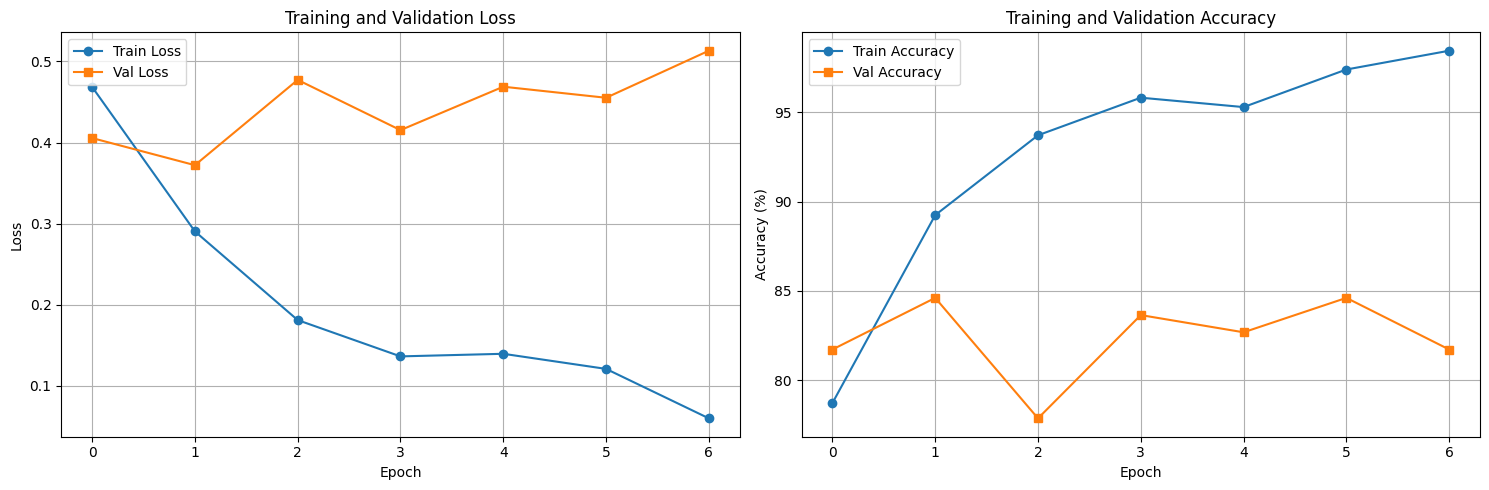

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracies
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(val_accuracies, label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


CLASSIFICATION REPORT
               precision    recall  f1-score   support

Fake News (0)     0.7407    0.6897    0.7143        29
Real News (1)     0.8831    0.9067    0.8947        75

     accuracy                         0.8462       104
    macro avg     0.8119    0.7982    0.8045       104
 weighted avg     0.8434    0.8462    0.8444       104


Confusion Matrix:
[[20  9]
 [ 7 68]]


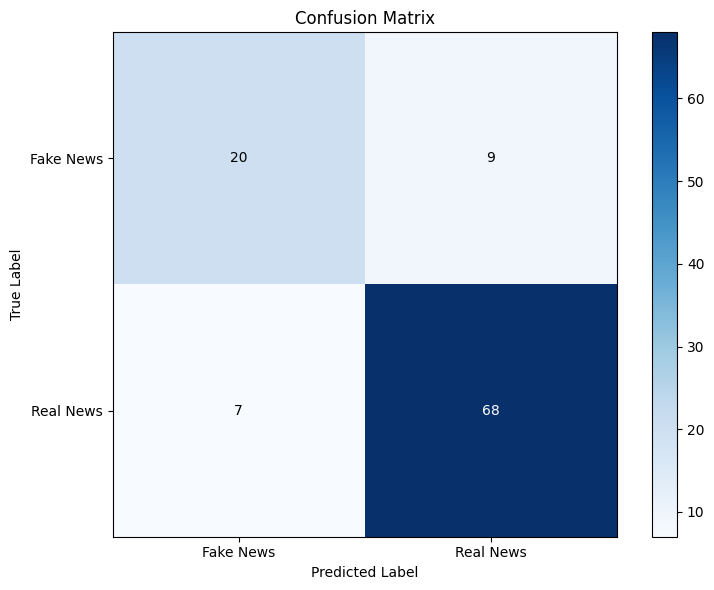

In [21]:
# Load best model
model.load_state_dict(torch.load(os.path.join(CACHE_DIR, 'best_model.pt')))
model.eval()

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    all_labels, 
    all_preds, 
    target_names=['Fake News (0)', 'Real News (1)'],
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fake News', 'Real News'])
plt.yticks(tick_marks, ['Fake News', 'Real News'])

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [22]:
def predict_fake_news(content_text, image_path):
    """
    Predict if a news article with image is fake or real
    
    Args:
        content_text: Text content of the news article
        image_path: Path to the associated image
    
    Returns:
        prediction: 0 (Fake) or 1 (Real)
        confidence: Confidence score
    """
    model.eval()
    
    # Extract all features
    text_features = extract_text_features(content_text)
    image_features = extract_image_features(image_path)
    
    ocr_text = extract_ocr_text(image_path)
    ocr_features = extract_text_features(ocr_text) if ocr_text else torch.zeros(768).to(device)
    
    caption = generate_image_caption(image_path)
    caption_features = extract_text_features(caption) if caption else torch.zeros(768).to(device)
    
    # Combine features
    combined_features = torch.cat([
        text_features,
        image_features,
        ocr_features,
        caption_features
    ]).unsqueeze(0)  # Add batch dimension
    
    # Make prediction
    with torch.no_grad():
        outputs = model(combined_features)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    prediction = predicted.item()
    confidence = confidence.item()
    
    label = "REAL NEWS" if prediction == 1 else "FAKE NEWS"
    
    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"\nExtracted OCR Text: {ocr_text[:100]}..." if ocr_text else "No OCR text found")
    print(f"Generated Caption: {caption}")
    
    return prediction, confidence


# Example usage
print("\n" + "="*50)
print("EXAMPLE PREDICTION")
print("="*50)

# Test on first sample from test set
sample_content = df_test.iloc[0]['content']
sample_image = os.path.join(IMG_DIR, df_test.iloc[0]['image'])
sample_true_label = df_test.iloc[0]['label']

print(f"True Label: {'REAL NEWS' if sample_true_label == 1 else 'FAKE NEWS'}")
predict_fake_news(sample_content, sample_image)


EXAMPLE PREDICTION
True Label: REAL NEWS

Prediction: FAKE NEWS
Confidence: 83.75%
No OCR text found
Generated Caption: 


(0, 0.8374987840652466)